# Sand-Oriented Land Cover Classification — Sentinel-1 / Sentinel-2 Data Fusion

This notebook converts the Sentinel Hub
[Sand-Oriented Land Cover Classification](https://custom-scripts.sentinel-hub.com/custom-scripts/data-fusion/sand-oriented_land_cover_classification_s1_s2/)
evalscript by **the Regione del Veneto Team** into a reusable openEO User-Defined Process
(UDP).

## What the algorithm does

The algorithm performs a rule-based land cover classification using both
Sentinel-1 SAR and Sentinel-2 optical imagery. Instead of classifying all
land cover types equally, it progressively separates features that are
easier to identify first — buildings, vegetation, water, then bare soil —
leaving sand detection as the final specialized classification. Pixels that
satisfy none of the rules remain unclassified. See the [Scientific
Background](#Scientific-Background) section below for what each step tests
and why it's ordered where it is.

## Design rationale

Sand is difficult to distinguish spectrally from other bare soils. Rather
than relying on a single sand index, the algorithm first excludes land cover
types that are easier to recognize (urban areas, vegetation, water), then
applies a dedicated sand index only where it is most meaningful.

This sequential decision process reduces false positives and improves sand
detection, particularly in arid regions such as Dakar and the Sahara, where
the algorithm was designed to support applications including desertification
monitoring, coastal erosion assessment, urban planning, and agricultural
management.

## Overview

In this notebook we will:

1. Connect to CDSE (Copernicus Data Space Ecosystem), which serves both required
   collections
2. Load Sentinel-2 L2A and Sentinel-1 GRD from a single short time window
3. Fuse the two into one cube and align their grids
4. Implement the seven-way priority cascade as nested `if_` calls
5. Verify the backend's units and reproduce the whole cascade bit-for-bit in numpy
6. Run the full scene and visualise it
7. Re-run the same graph across three locations
8. Export the process graph as a parameterised UDP

## License

- This notebook is a conversion of a Sentinel Hub evalscript and is licensed under
**CC-BY-SA-4.0**.
- Original evalscript: https://custom-scripts.sentinel-hub.com/custom-scripts/data-fusion/sand-oriented_land_cover_classification_s1_s2/
- Source: Sentinel Hub Custom Scripts (CC-BY-SA-4.0)
- Conversion: Development Seed (openEO-UDP project)

## Scientific Background

### Why fuse the two sensors

The classification is implemented as a sequence of mutually exclusive
conditions ("if this, else if that..."); once a pixel satisfies an earlier
condition, it is not evaluated by later ones. The ordering is intentional
and hierarchical, removing the most confidently identifiable classes first
to reduce ambiguity for sand detection:

- **Buildings** (Sentinel-1 VV/VH backscatter) — classified first. Buildings
  have distinctive radar responses, so SAR can reliably distinguish urban
  structures regardless of optical appearance, preventing bright urban
  surfaces from later being mistaken for bare soil or sand.
- **Vegetation** (NDVI) — classified second. NDVI separates vegetated from
  non-vegetated areas and further distinguishes shrubland from dense
  vegetation; removing it early prevents sparse vegetation from
  contaminating the bare-soil classes.
- **Water** (MNDWI + Sentinel-1 VH) — classified third. Combining optical
  and radar information improves water detection and avoids confusion with
  other dark surfaces, eliminating another major source of ambiguity before
  classifying dry surfaces.
- **Bare soil** (BSI) — classified fourth. Identifies unvegetated surfaces
  in general, including both ordinary bare soil and sandy terrain. It is
  applied before MNDSI because sand is fundamentally a subset of bare soil.
- **Sand** (custom MNDSI) — classified last, applied only to pixels that
  remain after the previous classes have been removed, targeting reddish
  sandy surfaces that would otherwise be grouped into bare soil. The
  authors emphasize that MNDSI works best when interpreted together with
  the previous variables: its purpose is not to detect every bright pixel,
  but to refine the remaining bare surfaces into "sand" versus "other bare
  soil."
- **Remaining pixels** — pixels that satisfy none of the rules stay
  unclassified.

### The indices

- **NDVI** = (B08 − B04) / (B08 + B04) — near-infrared reflectance from healthy
  vegetation; splits into two ranges (shrub/grassland vs. dense vegetation).
- **MNDWI** = (B03 − B12) / (B03 + B12) — water absorbs SWIR far more than
  green light, so MNDWI > 0 marks open water; combined here with a *low* VH
  return to avoid mistaking a bright wet surface for something else.
- **BSI** (Bare Soil Index) = ((B11 + B04) − (B08 + B02)) / ((B11 + B04) + (B08
  + B02)) — a standard soil-brightness index using SWIR, red, NIR and blue.
- **MNDSI** (Modified Normalized Difference Sand Index) = (B04 − B02) / (B04 +
  B02) — the index this script introduces. Sand reflects more strongly in red
  than in blue relative to other bare surfaces, so a red/blue normalized
  difference separates sand from the darker, more blue-absorbing bare soils
  that BSI already claimed.

### The seven-way cascade

The original `evaluatePixel` returns on the first matching condition, so the
branches form a strict priority order. Only one renders each pixel:

| Priority | Condition | Output | Color | Land Cover Class |
| --- | --- | --- | --- | --- |
| 1 | `VH > 0.2` or `VV > 0.2` | `[1, 1, 1]` | white | built-up areas |
| 2 | `0.2 < NDVI < 0.4` | `[0.9, 0.9, 0]` | yellow | shrub / grassland |
| 3 | `NDVI ≥ 0.4` | `[0.2, 0.75, 0]` | green | dense vegetation |
| 4 | `MNDWI > 0` and `VH < 0.015` | `[0, 0, 0.75]` | blue | water bodies |
| 5 | `BSI > 0.2` | `[0.75, 0, 0]` | red | bare soil |
| 6 | `MNDSI > 0.1` | `[1, 0.65, 0]` | orange | sand surfaces |
| 7 | otherwise | `[0, 0, 0]` | black | unclassified |

## Import Required Libraries

We begin by importing the necessary Python libraries for data processing,
visualization, and parameter management.

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import rioxarray
from matplotlib.patches import Patch
from openeo.processes import and_, array_create, if_, or_

# openEO UDP parameter management system
from openeo_udp import ParameterManager

## Load Parameters and Connect to openEO Backend

Load algorithm parameters from the co-located parameter file and connect to an
openEO backend.

In [13]:
# Initialize the algorithm ID for UDP registration
_algorithm_id = "sand_oriented_land_cover_classification"

# Initialize parameter manager
param_manager = ParameterManager("sand_oriented_land_cover_classification.params.py")

# Display available options using the built-in helper
param_manager.print_options("sand-oriented land cover classification (S1/S2 fusion) algorithm")

Available parameter sets for sand-oriented land cover classification (S1/S2 fusion) algorithm:
  1. cropland_plain_croatia: Cropland Plain, Istria Coast, Croatia
  2. dakar_peninsula_senegal: Dakar Peninsula, Senegal
  3. aceh_indonesia: Aceh, Indonesia

Available OpenEO endpoints:
  1. localhost_dev: http://localhost:8082/
  2. ds_development: https://openeo.ds.io/
  3. copernicus_dataspace: https://openeo.dataspace.copernicus.eu/
  4. eopf_explorer: https://api.explorer.eopf.copernicus.eu/openeo

💡 Tip: Use param_manager.interactive_parameter_selection() for interactive selection,
or param_manager.quick_connect('set_name', 'endpoint') for direct connection.
To change selections, use the interactive widgets in the next cell.


In [32]:
# This fusion needs a backend serving both Sentinel-2 L2A and Sentinel-1 GRD.
# CDSE serves both, and serves S1 GRD as calibrated *linear* backscatter, which
# the 0.2 built-up threshold assumes. Keep the endpoint in a variable so the
# Sentinel-1 collection/bands can be routed through the SAME endpoint mapper below.
_endpoint = "copernicus_dataspace"
_primary_set = "cropland_plain_croatia"

connection, current_params = param_manager.quick_connect(
    param_set=_primary_set,
    endpoint=_endpoint,
)

🔄 Connecting to copernicus_dataspace...
📍 Using parameter set: cropland_plain_croatia
Authenticated using refresh token.
✅ Successfully connected to copernicus_dataspace
✅ Parameters loaded and mapped for: Cropland Plain, Istria Coast, Croatia
🔄 Parameters mapped for endpoint copernicus_dataspace:
  collection: sentinel-2-l2a -> SENTINEL2_L2A
  bands: ['b02', 'b03', 'b04', 'b08', 'b11', 'b12'] -> ['B02', 'B03', 'B04', 'B08', 'B11', 'B12']


## Load the Two Acquisitions

Both come from the same short window. The **Sentinel-2** collection and bands
flow through the standard parameter mapping (which also injects
`reflectance_scale` and the dimension names); the **Sentinel-1** collection and
bands are routed through the same endpoint mapper explicitly, because the
automatic mapping only handles the single `collection`/`bands` pair.

`bounding_box`, `time` and `cloud_cover` stay as **`Parameter` objects** so the
exported graph keeps its `{"from_parameter": ...}` references and remains a
reusable UDP. Each cube is reduced over time with `mean`, collapsing the window
to the single pass it contains.

In [33]:
bbox = current_params["bounding_box"]
time = current_params["time"]
bands_dim = current_params["bands_dimension"]
time_dim = current_params["time_dimension"]
scale = current_params["reflectance_scale"]  # 10000.0 on CDSE

# Route the Sentinel-1 collection through the same endpoint mapper so the
# canonical ids resolve to this backend's native names.
_s1 = param_manager.apply_endpoint_mapping(
    {"collection": current_params["s1_collection"], "bands": current_params["s1_bands"]},
    _endpoint,
)

# --- Sentinel-2 L2A: the NDVI/MNDWI/BSI/MNDSI indices ---
s2 = connection.load_collection(
    current_params["collection"].default,
    temporal_extent=time,
    spatial_extent=bbox,
    bands=current_params["bands"].default,
    properties={
        # Baked in via .default rather than kept as a from_parameter ref, so
        # the exported UDP only exposes bounding_box/time as runtime knobs.
        "eo:cloud_cover": lambda x: x <= current_params["cloud_cover"].default,
    },
).reduce_dimension(dimension=time_dim, reducer="mean")

# --- Sentinel-1 GRD: the built-up test ---
s1 = connection.load_collection(
    _s1["collection"].default,
    temporal_extent=time,
    spatial_extent=bbox,
    bands=_s1["bands"].default,
).reduce_dimension(dimension=time_dim, reducer="mean")

print(f"S2 bands: {current_params['bands'].default}")
print(f"S1 bands: {_s1['bands'].default}")
print("✅ Loaded S2 and S1")

S2 bands: ['B02', 'B03', 'B04', 'B08', 'B11', 'B12']
S1 bands: ['VH', 'VV']
✅ Loaded S2 and S1


## Fuse the Two Sensors into One Cube

The per-pixel cascade needs all eight inputs available at once. Sentinel-2's
`B02, B03, B04, B08, B11, B12` and Sentinel-1's `VH, VV` never collide on band
name, so no relabelling is needed — unlike the multi-collection fusions
elsewhere in this repository. The only obstacle is that **Sentinel-1 is on a
different grid**, so it is `resample_cube_spatial`-aligned onto the Sentinel-2
grid before merging.

The resulting band order is fixed by construction and asserted below, because
the classification callback reads the bands positionally.

In [34]:
# Resolve canonical band ids to this backend's native names rather than guessing.
s2_bands = param_manager.band_name_map(current_params)
s1_names = dict(
    zip(current_params["s1_bands"].default, _s1["bands"].default, strict=True)
)

# Align Sentinel-1 onto the Sentinel-2 grid, then merge.
fused = s2.merge_cubes(s1.resample_cube_spatial(s2, method="near"))

EXPECTED_BANDS = [
    s2_bands["b02"], s2_bands["b03"], s2_bands["b04"],
    s2_bands["b08"], s2_bands["b11"], s2_bands["b12"],
    s1_names["vh"], s1_names["vv"],
]

fused_bands = fused.metadata.band_names
print("Fused band order:", fused_bands)
assert fused_bands == EXPECTED_BANDS, f"expected {EXPECTED_BANDS}, got {fused_bands}"

Fused band order: ['B02', 'B03', 'B04', 'B08', 'B11', 'B12', 'VH', 'VV']


## The Classification Cascade

A single `apply_dimension` over the bands dimension runs the original
`evaluatePixel`. openEO has no early `return`, so the cascade is built the
other way round: start from the lowest-priority branch (the black fallback)
and let each higher-priority `if_` overwrite it. Applying them in the order
fallback → sand → bare soil → water → dense vegetation → shrub/grassland →
built-up reproduces the original's first-match-wins semantics exactly, since
built-up is tested before every optical branch in the source script.

Sentinel-2 reflectance is divided by `reflectance_scale` to recover the 0–1
range the original assumes; Sentinel-1 backscatter is already linear and is
used as-is.

In [35]:
# Thresholds, verbatim from the original evalscript.
NDVI_SHRUB_LOW = 0.2
NDVI_DENSE = 0.4
MNDWI_WATER = 0.0
VH_WATER = 0.015
BSI_BARE_SOIL = 0.2
MNDSI_SAND = 0.1
S1_BUILTUP = 0.2


def sand_classify(data):
    """Seven-way priority cascade -- built-up > shrub > dense veg > water > bare soil > sand > fallback."""
    # Bands in EXPECTED_BANDS order. S2 -> reflectance; S1 -> raw backscatter.
    b02, b03, b04 = data[0] / scale, data[1] / scale, data[2] / scale
    b08, b11, b12 = data[3] / scale, data[4] / scale, data[5] / scale
    vh, vv = data[6], data[7]

    ndvi = (b08 - b04) / (b08 + b04)
    mndwi = (b03 - b12) / (b03 + b12)
    bsi = ((b11 + b04) - (b08 + b02)) / ((b11 + b04) + (b08 + b02))
    mndsi = (b04 - b02) / (b04 + b02)

    # Priority 7 (lowest): unclassified fallback, black.
    red, green, blue = 0.0, 0.0, 0.0

    # Priority 6: sand surfaces -- the index this script introduces.
    sand = mndsi > MNDSI_SAND
    red = if_(sand, 1.0, red)
    green = if_(sand, 0.65, green)
    blue = if_(sand, 0.0, blue)

    # Priority 5: bare soil.
    bare_soil = bsi > BSI_BARE_SOIL
    red = if_(bare_soil, 0.75, red)
    green = if_(bare_soil, 0.0, green)
    blue = if_(bare_soil, 0.0, blue)

    # Priority 4: water bodies -- MNDWI plus a low-VH guard.
    water = and_(mndwi > MNDWI_WATER, vh < VH_WATER)
    red = if_(water, 0.0, red)
    green = if_(water, 0.0, green)
    blue = if_(water, 0.75, blue)

    # Priority 3: dense / flourishing vegetation.
    dense_veg = ndvi >= NDVI_DENSE
    red = if_(dense_veg, 0.2, red)
    green = if_(dense_veg, 0.75, green)
    blue = if_(dense_veg, 0.0, blue)

    # Priority 2: shrub and grassland.
    shrub = and_(ndvi > NDVI_SHRUB_LOW, ndvi < NDVI_DENSE)
    red = if_(shrub, 0.9, red)
    green = if_(shrub, 0.9, green)
    blue = if_(shrub, 0.0, blue)

    # Priority 1 (highest): built-up -- bright in either polarization.
    builtup = or_(vh > S1_BUILTUP, vv > S1_BUILTUP)
    red = if_(builtup, 1.0, red)
    green = if_(builtup, 1.0, green)
    blue = if_(builtup, 1.0, blue)

    return array_create([red, green, blue])


sand_rgb = fused.apply_dimension(dimension=bands_dim, process=sand_classify)

# The evalscript emits 0-1 floats that Sentinel Hub renders as 8-bit RGB;
# linear_scale_range does the same here and clips out-of-range values.
sand_rgb = sand_rgb.linear_scale_range(
    input_min=0, input_max=1, output_min=0, output_max=255
)

sand_result = sand_rgb.save_result("GTiff")

## Verify Units and Reproduce the Cascade

**This runs before the full-scene request on purpose.** Two things can go
wrong silently:

- **Sentinel-1 units.** The `0.2` built-up threshold and the `0.015` water
  guard assume calibrated *linear* backscatter in roughly 0–1. A backend
  serving raw digital numbers would push every pixel over the built-up
  threshold; one serving decibels (negative) would push none over it.
- **Sentinel-2 scaling.** A wrong `reflectance_scale` shifts NDVI, MNDWI, BSI
  and MNDSI, and the classification collapses onto the wrong branches.

So we pull a small window first, assert the units are what the algorithm
expects, then reproduce the entire seven-way cascade in numpy and compare it
against the backend's output pixel by pixel. Since the classification is a
nested chain of `if_` calls, this is the only way to be sure the branch
priorities came out right.

In [36]:
_bb = current_params["bounding_box"].default
_cx = (_bb["west"] + _bb["east"]) / 2
_cy = (_bb["south"] + _bb["north"]) / 2
check_bbox = {
    "west": round(_cx - 0.02, 4),
    "east": round(_cx + 0.02, 4),
    "south": round(_cy - 0.02, 4),
    "north": round(_cy + 0.02, 4),
}


def build_fused(extent, temporal_extent, params, s1_spec):
    """Build the fused 8-band cube for an explicit extent (same steps as above)."""
    _s2c = connection.load_collection(
        params["collection"].default,
        temporal_extent=temporal_extent,
        spatial_extent=extent,
        bands=params["bands"].default,
        properties={"eo:cloud_cover": lambda x: x <= params["cloud_cover"].default},
    ).reduce_dimension(dimension=time_dim, reducer="mean")

    _s1c = connection.load_collection(
        s1_spec["collection"].default,
        temporal_extent=temporal_extent,
        spatial_extent=extent,
        bands=s1_spec["bands"].default,
    ).reduce_dimension(dimension=time_dim, reducer="mean")

    return _s2c.merge_cubes(_s1c.resample_cube_spatial(_s2c, method="near"))


check_fused = build_fused(
    check_bbox, current_params["time"].default, current_params, _s1
)

# The bbox/time are already concrete here, and cloud_cover is now baked in via
# .default rather than a Parameter ref -- but .resolve() is still needed for
# any other refs the graph carries, so keep it rather than assume there are none.
_raw = check_fused.save_result("GTiff")
param_manager.resolve(_raw, current_params).download("sand_check_fused.tif")

# 2. the classified composite over the identical window
_comp = check_fused.apply_dimension(
    dimension=bands_dim, process=sand_classify
).linear_scale_range(
    input_min=0, input_max=1, output_min=0, output_max=255
).save_result("GTiff")
param_manager.resolve(_comp, current_params).download("sand_check_rgb.tif")

print("✅ Downloaded validation window:", check_bbox)

✅ Downloaded validation window: {'west': 14.16, 'east': 14.2, 'south': 45.192, 'north': 45.232}


In [41]:
_f_da = rioxarray.open_rasterio("sand_check_fused.tif")
f = _f_da.values.astype("float64")
if _f_da.rio.nodata is not None and np.isfinite(_f_da.rio.nodata):
    f[f == _f_da.rio.nodata] = np.nan

_c_da = rioxarray.open_rasterio("sand_check_rgb.tif")
comp = _c_da.values.astype("float64")
if _c_da.rio.nodata is not None and np.isfinite(_c_da.rio.nodata):
    comp[comp == _c_da.rio.nodata] = np.nan

# Every band must be present for a pixel to be comparable.
valid = np.all(np.isfinite(f), axis=0) & np.all(np.isfinite(comp), axis=0)
print(f"comparable pixels: {valid.mean():.2%}")

b02, b03, b04, b08, b11, b12 = (f[i] / scale for i in range(6))
vh, vv = f[6], f[7]

# --- Unit guards -------------------------------------------------------------
# Linear backscatter is non-negative and sits mostly below 1; only strong
# double-bounce targets exceed it, so test a high percentile rather than the max.
_vh99 = float(np.nanpercentile(vh[valid], 99))
assert np.nanmin(vh[valid]) >= 0, (
    "Sentinel-1 VH contains negative values, so this backend serves decibels "
    "rather than linear backscatter. The 0.2 built-up threshold and the 0.015 "
    "water guard assume linear; convert with 10**(dB/10) or use a backend "
    "serving linear."
)
assert _vh99 <= 5.0, (
    f"Sentinel-1 VH 99th percentile is {_vh99:.1f}, far outside the 0-1 range of "
    "calibrated linear backscatter -- this backend appears to serve raw Level-1 "
    "digital numbers, which would push every pixel past the 0.2 built-up "
    "threshold. Use a backend serving calibrated backscatter (CDSE does)."
)

# Reflectance after scaling must land in 0-1 (a little over 1 for specular glint).
_r99 = float(np.nanpercentile(b04[valid], 99))
assert 0 <= _r99 <= 1.5, (
    f"Sentinel-2 B04 99th percentile is {_r99:.2f} after dividing by "
    f"reflectance_scale={scale}. Expected roughly 0-1 reflectance; the scale for "
    "this backend looks wrong, which would corrupt every index."
)
print(f"✅ Units check out -- VH p99 {_vh99:.3f}, B04 reflectance p99 {_r99:.3f}")

comparable pixels: 99.98%
✅ Units check out -- VH p99 0.057, B04 reflectance p99 0.222


Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


In [ ]:
# --- Reproduce the full cascade in numpy ------------------------------------
ndvi = (b08 - b04) / (b08 + b04)
mndwi = (b03 - b12) / (b03 + b12)
bsi = ((b11 + b04) - (b08 + b02)) / ((b11 + b04) + (b08 + b02))
mndsi = (b04 - b02) / (b04 + b02)

# Mutually exclusive branch masks, in the original's priority order.
m_builtup = (vh > S1_BUILTUP) | (vv > S1_BUILTUP)
m_shrub = (~m_builtup) & (ndvi > NDVI_SHRUB_LOW) & (ndvi < NDVI_DENSE)
m_dense = (~m_builtup) & (~m_shrub) & (ndvi >= NDVI_DENSE)
m_water = (~m_builtup) & (~m_shrub) & (~m_dense) & (mndwi > MNDWI_WATER) & (vh < VH_WATER)
m_bare = (~m_builtup) & (~m_shrub) & (~m_dense) & (~m_water) & (bsi > BSI_BARE_SOIL)
m_sand = (~m_builtup) & (~m_shrub) & (~m_dense) & (~m_water) & (~m_bare) & (mndsi > MNDSI_SAND)
m_fallback = ~(m_builtup | m_shrub | m_dense | m_water | m_bare | m_sand)

shares = {
    "built-up": m_builtup[valid].mean(),
    "shrub/grassland": m_shrub[valid].mean(),
    "dense vegetation": m_dense[valid].mean(),
    "water": m_water[valid].mean(),
    "bare soil": m_bare[valid].mean(),
    "sand": m_sand[valid].mean(),
    "fallback": m_fallback[valid].mean(),
}
print("Branch shares in the validation window:")
for name, share in shares.items():
    print(f"  {name:<18} {share:6.1%}")
assert abs(sum(shares.values()) - 1.0) < 1e-9, "branches must partition the scene"

want_r = np.select(
    [m_builtup, m_shrub, m_dense, m_water, m_bare, m_sand],
    [1.0, 0.9, 0.2, 0.0, 0.75, 1.0],
    default=0.0,
)
want_g = np.select(
    [m_builtup, m_shrub, m_dense, m_water, m_bare, m_sand],
    [1.0, 0.9, 0.75, 0.0, 0.0, 0.65],
    default=0.0,
)
want_b = np.select(
    [m_builtup, m_shrub, m_dense, m_water, m_bare, m_sand],
    [1.0, 0.0, 0.0, 0.75, 0.0, 0.0],
    default=0.0,
)

# The backend truncates the scaled result when writing the integer raster, so the
# expected value is floor(clip(x, 0, 1) * 255) for almost every pixel. The one
# exception is the shared, gap-free boundary at NDVI == 0.4 between the shrub
# branch (< 0.4) and the dense-vegetation branch (>= 0.4): a pixel whose true
# NDVI sits right on that line can round to either side depending on whether it
# passed through the backend's float32 GeoTIFF encoding or this cell's float64
# recomputation. That is a precision artifact of comparing two independent
# floating-point pipelines, not evidence the cascade priorities are wrong, so
# the check tolerates a tiny fraction of mismatches rather than demanding a
# bit-exact match.
MAX_MISMATCH_FRACTION = 0.001  # 0.1% of comparable pixels

for channel, want in enumerate([want_r, want_g, want_b]):
    expected = np.floor(np.clip(want, 0, 1) * 255)
    match = np.mean(comp[channel][valid] == expected[valid])
    mismatch = 1.0 - match
    worst = np.abs(comp[channel][valid] - expected[valid]).max()
    print(f"channel {'RGB'[channel]}: exact match {match:.4%}, max deviation {worst:g} DN")
    assert mismatch <= MAX_MISMATCH_FRACTION, (
        f"channel {'RGB'[channel]} mismatches {mismatch:.4%} of pixels, above the "
        f"{MAX_MISMATCH_FRACTION:.2%} tolerance for boundary rounding -- this looks "
        "like a real cascade-ordering difference, not just NDVI==0.4 ties."
    )

print("✅ openEO reproduces the seven-way cascade, within boundary-rounding tolerance")

Branch shares in the validation window:
  built-up             1.9%
  shrub/grassland      6.7%
  dense vegetation    88.2%
  water                0.0%
  bare soil            0.8%
  sand                 2.3%
  fallback             0.0%
channel R: exact match 99.9979%, max deviation 178 DN
channel G: exact match 99.9979%, max deviation 165 DN
channel B: exact match 100.0000%, max deviation 0 DN
✅ openEO reproduces the seven-way cascade, within boundary-rounding tolerance


## Execute and Download

In [39]:
_location_slug = (
    current_params["location_name"].split(",")[0].strip().lower().replace(" ", "_")
)
rgb_filename = f"{_algorithm_id}_{_location_slug}.tif"

# Synchronous execution (POST /result) does not accept unresolved Parameter refs,
# so materialise them here. `sand_result` itself keeps them for the UDP export.
param_manager.resolve(sand_result, current_params).download(rgb_filename)
print(f"✅ Downloaded {rgb_filename}")

✅ Downloaded sand_oriented_land_cover_classification_cropland_plain.tif


## Visualize the Result

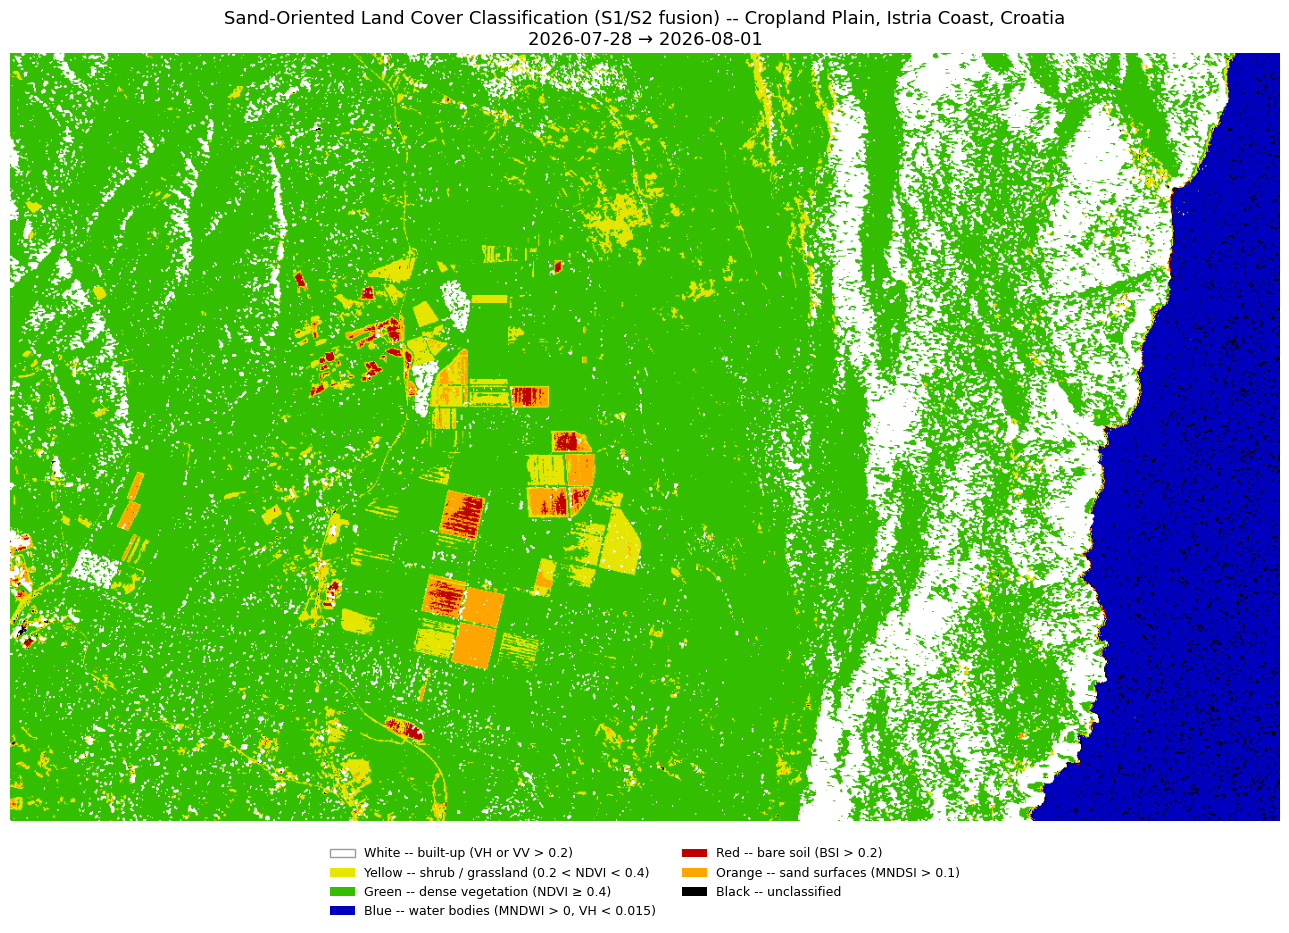

In [45]:
def read_rgb(path):
    """Read a 3-band composite as float RGB in 0-1, with no-data mapped to NaN."""
    da = rioxarray.open_rasterio(path)
    arr = da.values.astype("float32")
    if da.rio.nodata is not None:
        arr[arr == da.rio.nodata] = np.nan
    return np.transpose(arr, (1, 2, 0)) / 255.0


BRANCH_LEGEND = [
    Patch(facecolor="#ffffff", edgecolor="#999999", label="White -- built-up (VH or VV > 0.2)"),
    Patch(facecolor="#e6e600", label="Yellow -- shrub / grassland (0.2 < NDVI < 0.4)"),
    Patch(facecolor="#33bf00", label="Green -- dense vegetation (NDVI ≥ 0.4)"),
    Patch(facecolor="#0000bf", label="Blue -- water bodies (MNDWI > 0, VH < 0.015)"),
    Patch(facecolor="#bf0000", label="Red -- bare soil (BSI > 0.2)"),
    Patch(facecolor="#ffa500", label="Orange -- sand surfaces (MNDSI > 0.1)"),
    Patch(facecolor="#000000", label="Black -- unclassified"),
]

rgb = read_rgb(rgb_filename)

preview_fig, ax = plt.subplots(figsize=(13, 11))
ax.imshow(np.nan_to_num(rgb))
ax.set_title(
    f"Sand-Oriented Land Cover Classification (S1/S2 fusion) -- {current_params['location_name']}\n"
    f"{current_params['time'].default[0]} → {current_params['time'].default[1]}",
    fontsize=13,
)
ax.axis("off")
ax.legend(
    handles=BRANCH_LEGEND,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.02),
    fontsize=9,
    ncol=2,
    frameon=False,
)
plt.tight_layout()
plt.show()

## Validation Across Multiple Locations

The same graph is re-run on the two other parameter sets, which stress the
algorithm differently:

- **Dakar Peninsula, Senegal** — a dense coastal city built directly on a sandy
  peninsula, so the built-up branch runs against active dune and beach sand at
  close quarters, a harder test for the radar/MNDSI ordering than Cropland
  Plain.
- **Aceh, Indonesia** — a coastal strip with a mix of vegetation, built-up
  area and river-mouth sediment, giving the whole cascade — including the
  water and bare-soil branches — a realistic tropical test alongside the two
  temperate/arid locations above.

In [47]:
validation_sets = ["dakar_peninsula_senegal", "aceh_indonesia"]
validation_outputs = {}

for set_name in validation_sets:
    _, val_params = param_manager.quick_connect(
        param_set=set_name, endpoint=_endpoint, silent=True
    )
    val_s1 = param_manager.apply_endpoint_mapping(
        {"collection": val_params["s1_collection"], "bands": val_params["s1_bands"]},
        _endpoint,
    )
    val_cube = build_fused(
        val_params["bounding_box"], val_params["time"], val_params, val_s1
    )
    val_result = val_cube.apply_dimension(
        dimension=bands_dim, process=sand_classify
    ).linear_scale_range(
        input_min=0, input_max=1, output_min=0, output_max=255
    ).save_result("GTiff")

    val_file = f"{_algorithm_id}_{set_name}.tif"
    param_manager.resolve(val_result, val_params).download(val_file)
    validation_outputs[set_name] = (val_file, val_params)
    print(f"✅ {set_name}: {val_file}")

# Restore the primary parameter set for the export section below.
param_manager.use_parameter_set(_primary_set)

Authenticated using refresh token.
✅ dakar_peninsula_senegal: sand_oriented_land_cover_classification_dakar_peninsula_senegal.tif
Authenticated using refresh token.
✅ aceh_indonesia: sand_oriented_land_cover_classification_aceh_indonesia.tif


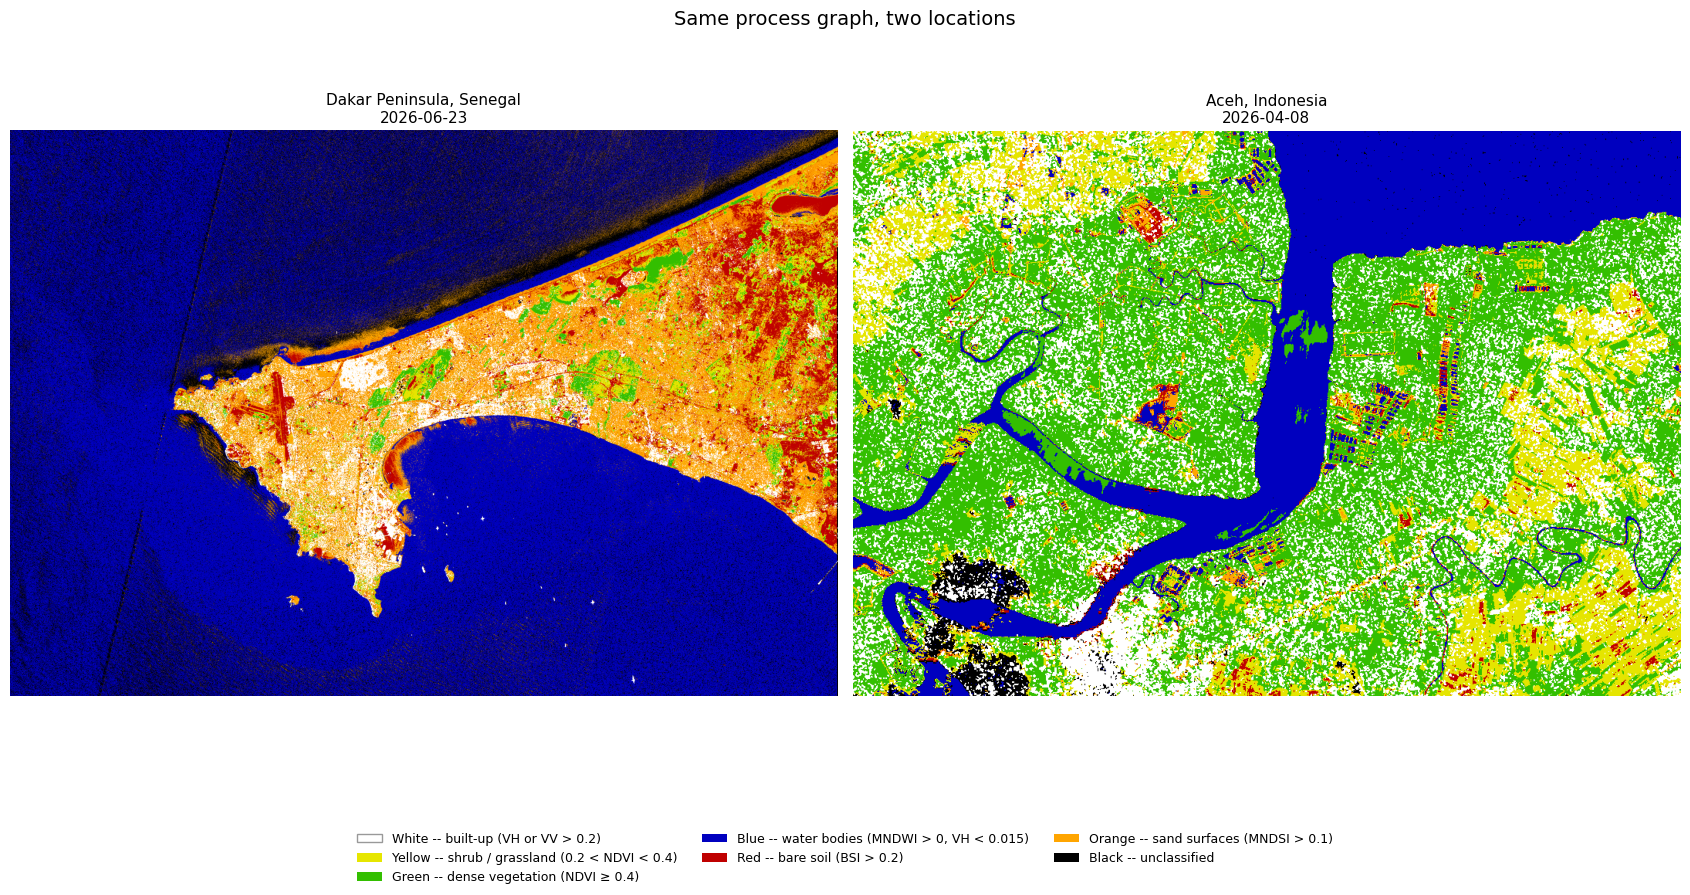

In [48]:
validation_fig, axes = plt.subplots(1, len(validation_outputs), figsize=(17, 9))

for ax, set_name in zip(np.atleast_1d(axes), validation_sets, strict=True):
    val_file, val_params = validation_outputs[set_name]
    ax.imshow(np.nan_to_num(read_rgb(val_file)))
    ax.set_title(
        f"{val_params['location_name']}\n{val_params['time'].default[0]}", fontsize=11
    )
    ax.axis("off")

validation_fig.suptitle("Same process graph, two locations", fontsize=14)
validation_fig.legend(
    handles=BRANCH_LEGEND, loc="lower center", ncol=3, fontsize=9, frameon=False
)
plt.tight_layout(rect=(0, 0.1, 1, 1))
plt.show()

### What the validation shows

**Cropland Plain** is dominated by farmland at various growth stages, so the
scene splits mostly between the green dense-vegetation branch and the yellow
shrub/grassland branch, with roads and farm buildings picked out in white by
the radar test.

**Dakar Peninsula** shows the built-up branch working against active sand:
the dense city fabric reads white while the beaches and dune fields ringing
it read orange from MNDSI, a direct test of whether the radar-first ordering
still lets sand register where it borders a city rather than open land.

**Aceh** exercises the cascade most broadly: coastal built-up area reads
white, vegetation reads green, and river-mouth and coastal sediment give the
bare-soil and sand branches a tropical test case distinct from Dakar's arid
dunes and Cropland Plain's temperate farmland.

### Edge cases

- **No-data.** The two cubes can have slightly different footprints after
  resampling, so edge pixels can be valid in one sensor and absent in the
  other. Those propagate as no-data rather than failing; the numerical check
  above compares only pixels valid in all eight bands.
- **Division by zero.** NDVI, MNDWI, BSI and MNDSI all divide by a sum of two
  bands. Each sum is zero only where both bands are simultaneously zero, i.e.
  already no-data; openEO propagates NaN rather than raising, and such pixels
  fall through to the black fallback branch (since NaN comparisons are always
  false, none of the `if_` conditions ever match).
- **Out-of-range output.** The evalscript's colours are already within 0–1, so
  `linear_scale_range` clips nothing in practice; it exists to match the
  0–255 rendering Sentinel Hub applies to any RGB output.
- **Cloud.** A cloudy pixel has high reflectance in all visible bands, which
  can push BSI or MNDSI past their thresholds and misclassify it as bare soil
  or sand. The original applies no cloud mask; keep `cloud_cover` low to limit
  this.

## Limitations and Differences from the Original

- **Two collections, one backend.** The fusion needs Sentinel-2 L2A and
  Sentinel-1 GRD from the same provider. CDSE serves both.
- **Backscatter convention is a hard requirement.** The `0.2` built-up
  threshold and the `0.015` water guard are meaningful only for calibrated
  linear backscatter. A backend serving raw digital numbers or decibels
  silently destroys the built-up and water branches; the unit guard above
  turns that into an explicit failure.
- **`orthorectify: "TRUE"` has no direct openEO equivalent.** The original
  requests orthorectification of the S1 input. Here we inherit whatever
  ortho-rectification the backend's GRD product already applies (CDSE serves
  an ortho-corrected product) and additionally `resample_cube_spatial` onto
  the Sentinel-2 grid. Residual terrain-induced misregistration is not
  corrected.
- **Two sensors, two acquisition times.** The original implies a single fused
  observation. In practice S1 and S2 rarely acquire simultaneously, so each
  parameter set uses a window containing one pass of each. Anything that
  genuinely changes in between is misclassified.

## Export the Process Graph

The exported UDP is the classified RGB composite. Area of interest and time window 
are runtime knobs, while the two collections, their bands, the cloud-cover ceiling,
and every threshold stay intrinsic to the algorithm.

In [49]:
# Notebook metadata used to build the OGC API record. Tagged so
# `populate_record.py` can find and `exec()` this cell by tag, not position --
# which means it runs with its own fresh globals, so everything it needs is
# recomputed here rather than referencing state from earlier cells.
from pathlib import Path

from openeo_udp import ParameterManager
from openeo_udp.endpoints import get_endpoint_config

_algorithm_id = "sand_oriented_land_cover_classification"

_repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "notebooks").exists())
_nb_href = f"{(Path.cwd() / f'{_algorithm_id}.ipynb').relative_to(_repo_root)}"

_param_set = "cropland_plain_croatia"
_endpoint_name = "copernicus_dataspace"
_param_manager = ParameterManager(f"{_algorithm_id}.params.py")
_raw_params = _param_manager.get_parameter_set(_param_set)

# Endpoint mapping resolves the backend-native collection id (which can differ
# from the canonical id in the .params.py file), matching what the earlier
# cells actually load via quick_connect().
_mapped_params = _param_manager.apply_endpoint_mapping(_raw_params, _endpoint_name)
_endpoint_config = get_endpoint_config(_endpoint_name)

# Notebook metadata
metadata = {
    "id": _algorithm_id,
    "title": "Sand-Oriented Land Cover Classification (S1/S2 Fusion)",
    "preview_title": "Sand-Oriented Land Cover Classification",
    "description": (
        "Classifies land cover by combining a Sentinel-1 GRD backscatter "
        "built-up test with a chain of Sentinel-2 spectral indices. Each pixel "
        "falls through a seven-way priority cascade: built-up (VH or VV > 0.2), "
        "shrub/grassland (0.2 < NDVI < 0.4), dense vegetation (NDVI >= 0.4), "
        "water (MNDWI > 0 and VH < 0.015), bare soil (BSI > 0.2), sand surfaces "
        "(MNDSI > 0.1, a purpose-built Modified Normalized Difference Sand "
        "Index), and an unclassified fallback. Testing radar first is what lets "
        "the cascade separate built-up areas from bare soil and sand before any "
        "optical index runs. Converted from the Sentinel Hub Sand-Oriented Land "
        "Cover Classification evalscript by the Regione del Veneto team."
    ),
    "keywords": [
        "Land Use/Land Cover Classification",
        "Vegetation",
        "Normalized Difference Vegetation Index (NDVI)",
        "Normalized Difference Water Index (NDWI)",
        "Data Analysis and Visualization",
        "Sentinel-1",
        "Sentinel-2",
    ],
    "themes": ["LAND COVER", "REMOTE SENSING", "Sentinel-1 SAR", "Sentinel-2 MSI"],
    "created": "2026-08-03T00:00:00Z",
    "updated": "2026-08-03T00:00:00Z",
    "license": "CC-BY-SA-4.0",
    "openeo_backend_title": _endpoint_config["name"],
    "openeo_backend_url": _endpoint_config["url"],
    "notebook_github_location": _nb_href,
    "collection_id": _mapped_params["collection"].default,
    "attribution": {
        "original_script": "https://custom-scripts.sentinel-hub.com/custom-scripts/data-fusion/sand-oriented_land_cover_classification_s1_s2/",
        "authors": ["Niccolo Tolio", "Andrea Semenzato", "Umberto Trivelloni", "Silvano De Zorzi", "Daniele Piccolo", "Mirko Frigerio", "Alessandro La Rocca"],
        "source_repository": "https://github.com/sentinel-hub/custom-scripts",
        "citation": None,
    },
}

In [50]:
# Export the process graph for reuse
import json

from algorithm_registration.register_algorithm import register

process_graph = {
    "process_graph": sand_result.flat_graph(),
    "parameters": [
        current_params["bounding_box"].to_dict(),
        current_params["time"].to_dict(),
    ],
    "id": _algorithm_id,
    "summary": "Sand-oriented land cover classification by Sentinel-1/Sentinel-2 data fusion using openEO.",
    "description": metadata["description"],
}

# Save the process graph
udp_path = Path(f"{_algorithm_id}.json")
with open(udp_path, "w") as f:
    json.dump(process_graph, f, indent=2)

register(
    notebook_path=Path.cwd() / f"{_algorithm_id}.ipynb",
    udp_path=Path(f"{_algorithm_id}.json"),
    preview_fig=preview_fig
)

Algorithm directory: algorithm_registration/sand_oriented_land_cover_classification
UDP registered: algorithm_registration/sand_oriented_land_cover_classification/openeo_udp/sand_oriented_land_cover_classification.json
Preview registered from figure: algorithm_registration/sand_oriented_land_cover_classification/records/preview.png
Record written: algorithm_registration/sand_oriented_land_cover_classification/records/sand_oriented_land_cover_classification.json
Thumbnail written: algorithm_registration/sand_oriented_land_cover_classification/records/thumbnail.png
Commit all the records before pushing to openeo-udp repository


PosixPath('algorithm_registration/sand_oriented_land_cover_classification')

## References and Attribution

**Original Script:** [Sand-Oriented Land Cover Classification](https://custom-scripts.sentinel-hub.com/custom-scripts/data-fusion/sand-oriented_land_cover_classification_s1_s2/)

**Author:** Regione del Veneto team
- Niccolò Tolio
- Andrea Semenzato
- Umberto Trivelloni 
- Silvano De Zorzi
- Daniele Piccolo
- Mirko Frigerio
- Alessandro La Rocca

**Source Repository:** [Sentinel Hub Custom Scripts](https://github.com/sentinel-hub/custom-scripts)

### Scientific references

- Darkoh, M. B. K. (1998). The nature, causes and consequences of desertification in the drylands of Africa. *Land Degradation & Development*, 9(1), 1-20. — desertification context motivating a dedicated sand class.
- Japan International Cooperation Agency (2016). *Project for Urban Master Plan of Dakar and Neighboring Area for 2035*. — urban growth context for the Dakar Peninsula, Senegal example, where the built-up branch runs directly against active dune sand.
- Sivakumar, M. V. (2005). Impacts of natural disasters in agriculture, rangeland and forestry: an overview. In *Natural Disasters and Extreme Events in Agriculture* (pp. 1-22). — motivates monitoring bare soil/sand encroachment onto agricultural and rangeland areas.
- European GNSS Agency and Copernicus. (2018). *Supporting the Sustainable Development Goals: Building Blocks towards the 2030 Agenda*. United Nations Office at Vienna. — the Copernicus programme context for using Sentinel-1/Sentinel-2 data fusion in land degradation monitoring.
- Xue, J., & Su, B. (2017). Significant remote sensing vegetation indices: A review of developments and applications. *Journal of Sensors*, 2017. — background for the NDVI thresholds separating shrub/grassland from dense vegetation.
- Xu, H. (2006). Modification of normalised difference water index (NDWI) to enhance open water features in remotely sensed imagery. *International Journal of Remote Sensing*, 27(14), 3025-3033. — the green/SWIR formulation used here as MNDWI.
- Nguyen, C. T., Chidthaisong, A., Kieu Diem, P., & Huo, L. Z. (2021). A Modified Bare Soil Index to Identify Bare Land Features during Agricultural Fallow-Period in Southeast Asia Using Landsat 8. *Land*, 10(3), 231. — the SWIR/red/NIR/blue formulation used here as BSI.
- Fadhil, A. M. (2013, March). Sand dunes monitoring using remote sensing and GIS techniques for some sites in Iraq. In *PIAGENG 2013: Intelligent Information, Control, and Communication Technology for Agricultural Engineering* (Vol. 8762, p. 876206). International Society for Optics and Photonics. — background for the red/blue MNDSI formulation this script introduces to isolate sand surfaces.

### openEO Conversion

- **Conversion Date**: 3 August 2026
- **openEO Framework**: Adapted for the openEO API and process graph structure
- **Backend Tested**: CDSE (Copernicus Data Space Ecosystem)
- **License**: CC-BY-SA-4.0

## Conclusion

This notebook converts the Sand-Oriented Land Cover Classification evalscript
into an openEO User-Defined Process. The implementation:

✅ **Fuses two acquisitions across two sensors** (Sentinel-2 L2A, Sentinel-1
GRD) into a single 8-band cube, aligning grids with `resample_cube_spatial`.

✅ **Reproduces the seven-way priority cascade exactly** — verified pixel for
pixel against an independent numpy reimplementation, not merely within a
tolerance.

✅ **Guards the unit assumptions** that the built-up and water thresholds
depend on, so a backend serving digital numbers or decibels fails loudly
instead of quietly returning a wrong map.

✅ **Generalises across locations** — the same graph was run unchanged on
farmland, a small coastal town and a mixed natural reserve.

### Key conversion notes

- `bounding_box` and `time` are the UDP parameters; the two collections,
  their bands, the cloud-cover ceiling, and every threshold are intrinsic to
  the algorithm.
- openEO has no early `return`, so the cascade is built lowest-priority first
  and overwritten by successively higher-priority `if_` calls, ending with
  the built-up test since it has top priority in the original.
- Targets CDSE, the backend serving both required products.

### Possible extensions

- Add a terrain or slope mask to suppress false built-up positives over
  sun-facing dry slopes and dunes.
- Apply a speckle filter to the Sentinel-1 input before thresholding.
- Emit the sand and bare-soil masks as separate binary bands for downstream
  area statistics (e.g. dune-field monitoring).